# **MVP — Machine Learning & Analytics**

**Nome:** _Vinícius Araújo Moraes da Silva_  
**Matrícula:** _4052026000096_  
**Data:** _24/06/2026_  
**Dataset:** _Heart Disease Dataset_  
**Link da fonte:** https://archive.ics.uci.edu/dataset/45/heart+disease  
**Tipo de problema:** _Classificação Supervisionada (Classificação Binária)_

# 1. Definição do problema
## 1.1 Descrição do problema

As doenças cardiovasculares estão entre as principais causas de morte no mundo, e seu diagnóstico precoce é um desafio importante na área da saúde.

Neste contexto, o objetivo é prever, com base em dados clínicos, se um paciente apresenta ou não sinais de doença cardíaca. Trata-se de um problema de classificação supervisionada, que pode apoiar a triagem e a tomada de decisão médica, sem substituir a avaliação profissional.

## 1.2 Objetivo do MVP

O objetivo deste MVP é prever a presença de doença cardíaca em pacientes com modelos de Machine Learning de classificação supervisionada, usando o Heart Disease Dataset.

Serão feitas etapas básicas de análise, pré-processamento, treinamento e avaliação dos modelos, comparando seu desempenho por métricas como acurácia, precisão, recall, F1-score e AUC-ROC.

## 1.3 Tipo de problema

**Tipo escolhido:** Classificação Supervisionada (Classificação Binária).

**Justificativa:**

O problema deste MVP é de **classificação supervisionada**, pois o objetivo é prever se o paciente tem ou não doença cardíaca com base em suas características clínicas. A variável alvo possui duas classes: **0 (ausência)** e **1 (presença)**.

Não se trata de regressão, clusterização ou séries temporais, já que os dados já possuem rótulos e não seguem uma ordem cronológica. Portanto, a melhor abordagem é usar algoritmos de classificação para identificar padrões e fazer previsões em novos pacientes.



## 1.4 Premissas, hipóteses e critérios de sucesso

Liste as principais hipóteses e como você pretende verificar se o MVP foi bem-sucedido.

**Hipóteses iniciais:**

**Hipótese 1:** Os dados clínicos e demográficos podem indicar a presença de doença cardíaca.

**Hipótese 2:** Modelos supervisionados devem prever a doença cardíaca melhor que um baseline.

**Hipótese 3:** O pré-processamento dos dados pode melhorar o desempenho dos modelos.

**Métrica principal:** O **F1-score** será a métrica principal, por equilibrar precisão e recall. Também serão observadas acurácia, precisão, recall, matriz de confusão e AUC-ROC.

**Resultado mínimo esperado:** Espera-se que ao menos um modelo supere o baseline e alcance **F1-score** e acurácia de pelo menos **80%** no teste.

**Restrição prática:** O modelo deve generalizar bem, ter baixo custo computacional e ser interpretável, para apoiar a decisão clínica.



# 2. Ambiente, bibliotecas e reprodutibilidade

In [100]:
# === Setup básico e reprodutibilidade ===
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, TimeSeriesSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score, recall_score, precision_score
)
from scipy.stats import randint

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)

Python: 3.12.13
Seed: 42


## 2.1 Dependências adicionais

In [101]:
# Exemplo: descomente apenas se necessário.
# !pip install -q imbalanced-learn xgboost lightgbm catboost optuna # modelos extras
# !pip install -q seaborn plotly # visualização
# !pip install -q statsmodels pmdarima # cálculo de estatísticas (extras)

## 2.2 Funções auxiliares

In [102]:
def evaluate_classification(y_true, y_pred, proba=None):
    """Calcula métricas básicas para classificação."""
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted")
    }

    # ROC AUC é mais direto para classificação binária com probabilidades.
    try:
        if proba is not None and proba.shape[1] == 2:
            results["roc_auc"] = roc_auc_score(y_true, proba[:, 1])
        else:
            results["roc_auc"] = np.nan
    except Exception:
        results["roc_auc"] = np.nan

    return results


def evaluate_regression(y_true, y_pred):
    """Calcula métricas básicas para regressão."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }


def show_results_table(results_dict):
    """Exibe resultados como DataFrame ordenável."""
    return pd.DataFrame(results_dict).T

# 3. Seleção e carga dos dados
## 3.1 Fonte dos dados

O dataset utilizado neste MVP é o **Heart Disease Dataset**, disponível no repositório **UCI Machine Learning Repository**. O conjunto de dados pode ser acessado pelo seguinte link:

https://archive.ics.uci.edu/dataset/45/heart+disease

O dataset foi escolhido por ser amplamente utilizado em estudos de Machine Learning, possuir um problema de classificação binária bem definido e apresentar um conjunto de atributos clínicos adequado para o desenvolvimento e avaliação de modelos preditivos.

Os dados são públicos, anonimizados e disponibilizados para fins de pesquisa e ensino, não contendo informações que permitam a identificação dos pacientes. Dessa forma, não há restrições relacionadas à privacidade dos indivíduos, desde que o uso respeite os termos de licença e atribuição da fonte.


In [103]:
from sklearn.datasets import fetch_openml

# Carregar o dataset
heart = fetch_openml(name="heart-disease", version=1, as_frame=True)

## dataset pelo github
## url = "https://raw.githubusercontent.com/vinicius-datatech/uci-heart-disease-dataset/refs/heads/main/heart-statlog.csv"

df = pd.read_csv(url)

# Converter para DataFrame
df = heart.frame

# Visualizar as 10 primeiras linhas
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,3.0,145.0,233.0,1.0,0.0,150.0,0.0,2.3,0.0,0.0,1.0,1.0
1,37.0,1.0,2.0,130.0,250.0,0.0,1.0,187.0,0.0,3.5,0.0,0.0,2.0,1.0
2,41.0,0.0,1.0,130.0,204.0,0.0,0.0,172.0,0.0,1.4,2.0,0.0,2.0,1.0
3,56.0,1.0,1.0,120.0,236.0,0.0,1.0,178.0,0.0,0.8,2.0,0.0,2.0,1.0
4,57.0,0.0,0.0,120.0,354.0,0.0,1.0,163.0,1.0,0.6,2.0,0.0,2.0,1.0
5,57.0,1.0,0.0,140.0,192.0,0.0,1.0,148.0,0.0,0.4,1.0,0.0,1.0,1.0
6,56.0,0.0,1.0,140.0,294.0,0.0,0.0,153.0,0.0,1.3,1.0,0.0,2.0,1.0
7,44.0,1.0,1.0,120.0,263.0,0.0,1.0,173.0,0.0,0.0,2.0,0.0,3.0,1.0
8,52.0,1.0,2.0,172.0,199.0,1.0,1.0,162.0,0.0,0.5,2.0,0.0,3.0,1.0
9,57.0,1.0,2.0,150.0,168.0,0.0,1.0,174.0,0.0,1.6,2.0,0.0,2.0,1.0


## 3.3 Visão geral do dataset

In [104]:
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Formato do dataset: (303, 14)

Tipos de dados:


,tipo
age,float64
sex,float64
cp,float64
trestbps,float64
chol,float64
fbs,float64
restecg,float64
thalach,float64
exang,float64
oldpeak,float64


In [105]:
print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [106]:
print("\nDuplicatas:", df.duplicated().sum())


Duplicatas: 1


In [107]:
display(df.sample(5, random_state=SEED))

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
179,57.0,1.0,0.0,150.0,276.0,0.0,0.0,112.0,1.0,0.6,1.0,1.0,1.0,0.0
228,59.0,1.0,3.0,170.0,288.0,0.0,0.0,159.0,0.0,0.2,1.0,0.0,3.0,0.0
111,57.0,1.0,2.0,150.0,126.0,1.0,1.0,173.0,0.0,0.2,2.0,1.0,3.0,1.0
246,56.0,0.0,0.0,134.0,409.0,0.0,0.0,150.0,1.0,1.9,1.0,2.0,3.0,0.0
60,71.0,0.0,2.0,110.0,265.0,1.0,0.0,130.0,0.0,0.0,2.0,1.0,2.0,1.0


## 3.4 Dicionário de dados

| Atributo | Descrição                                                      | Tipo       |
| -------- | -------------------------------------------------------------- | ---------- |
| age      | Idade do paciente                                              | Numérico   |
| sex      | Sexo (0 = Masculino, 1 = Feminino)                             | Categórico |
| cp       | Tipo de dor no peito                                           | Categórico |
| trestbps | Pressão arterial em repouso (mmHg)                             | Numérico   |
| chol     | Colesterol sérico (mg/dL)                                      | Numérico   |
| fbs      | Glicemia em jejum > 120 mg/dL (0 = não, 1 = sim)               | Categórico |
| restecg  | Resultado do eletrocardiograma em repouso                      | Categórico |
| thalach  | Frequência cardíaca máxima atingida                            | Numérico   |
| exang    | Angina induzida por exercício (0 = não, 1 = sim)               | Categórico |
| oldpeak  | Depressão do segmento ST induzida por exercício                | Numérico   |
| slope    | Inclinação do segmento ST                                      | Categórico |
| ca       | Número de grandes vasos observados por fluoroscopia            | Numérico   |
| thal     | Resultado do exame de talassemia                               | Categórico |
| num   | Variável alvo: presença (1) ou ausência (0) de doença cardíaca | Categórico |


# 4. Análise exploratória dos dados

In [108]:
# Ajuste das variáveis do problema

TARGET = "target"
PROBLEM_TYPE = "classificacao"

if TARGET is not None and TARGET in df.columns:
    print("Distribuição da variável alvo:")
    display(df[TARGET].value_counts(dropna=False).to_frame("Contagem"))

    display(
        (df[TARGET].value_counts(normalize=True, dropna=False) * 100)
        .round(2)
        .to_frame("Percentual (%)")
    )

Distribuição da variável alvo:


,Contagem
target,
1.0,165
0.0,138


,Percentual (%)
target,
1.0,54.46
0.0,45.54


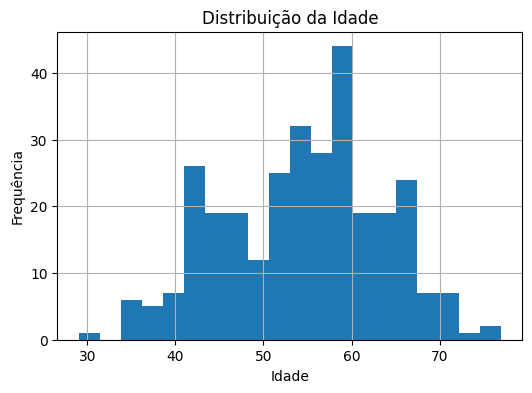

In [109]:
# Distribuição da idade
plt.figure(figsize=(6,4))
df["age"].hist(bins=20)
plt.title("Distribuição da Idade")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.show()

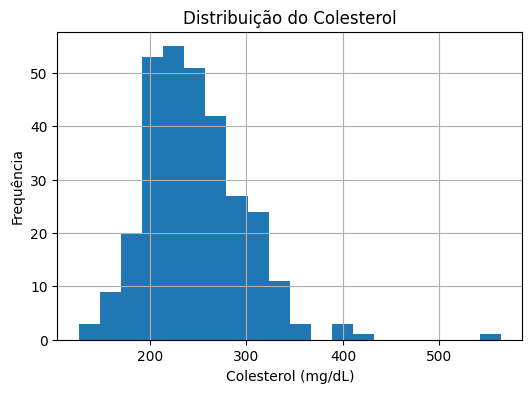

In [110]:
# Distribuição do colesterol
plt.figure(figsize=(6,4))
df["chol"].hist(bins=20)
plt.title("Distribuição do Colesterol")
plt.xlabel("Colesterol (mg/dL)")
plt.ylabel("Frequência")
plt.show()

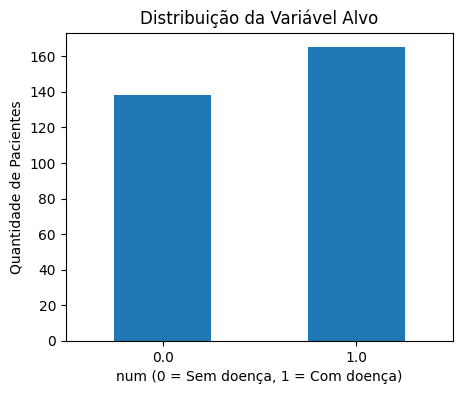

In [111]:
# Distribuição da variável alvo
plt.figure(figsize=(5,4))
df["target"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribuição da Variável Alvo")
plt.xlabel("num (0 = Sem doença, 1 = Com doença)")
plt.ylabel("Quantidade de Pacientes")
plt.xticks(rotation=0)
plt.show()

## 4.1 Síntese da análise exploratória

A análise exploratória indicou que os dados apresentam boa qualidade geral, com poucos problemas de inconsistência e uma distribuição equilibrada da variável alvo. Isso é positivo para o desenvolvimento do modelo, pois reduz riscos de viés e favorece uma avaliação mais confiável dos algoritmos de classificação.

Além disso, foi identificada a necessidade de padronizar algumas variáveis numéricas antes do treinamento. Essa etapa é importante porque diferentes escalas podem influenciar o desempenho de certos modelos, e o pré-processamento adequado tende a melhorar os resultados finais.


# 5. Preparação dos dados e divisão treino/teste

In [112]:
# === Configuração do problema ===

TARGET = "target"
PROBLEM_TYPE = "classificacao"

ID_COLUMNS = []      # O dataset não possui coluna de identificação
DATE_COLUMN = None   # Não há coluna de data
DROP_COLUMNS = []    # Nenhuma coluna será removida nesta etapa

assert TARGET in df.columns, "Defina um TARGET válido."

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)
columns_to_exclude.add(TARGET)

features = [c for c in df.columns if c not in columns_to_exclude]

print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)

## Essas são as 13 variáveis preditoras utilizadas para prever a variável alvo (target), que indica a presença ou ausência de doença cardíaca.

Tipo de problema: classificacao
Target: target
Número de features: 13
Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [113]:
# === Divisão dos dados ===

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    X = df[features].copy()
    y = df[TARGET].copy()

    stratify_arg = y if PROBLEM_TYPE == "classificacao" else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=stratify_arg
    )

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "clusterizacao":
    X = df[features].copy()
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=SEED)
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "serie_temporal":
    assert DATE_COLUMN is not None and DATE_COLUMN in df.columns, "Defina DATE_COLUMN para séries temporais."
    df_sorted = df.sort_values(DATE_COLUMN).copy()
    cutoff = int(len(df_sorted) * 0.8)
    train_df = df_sorted.iloc[:cutoff]
    test_df = df_sorted.iloc[cutoff:]

    X_train = train_df[features].copy()
    y_train = train_df[TARGET].copy()
    X_test = test_df[features].copy()
    y_test = test_df[TARGET].copy()

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

else:
    raise ValueError("PROBLEM_TYPE inválido.")

Treino: (242, 13) | Teste: (61, 13)


## 5.1 Justificativa da divisão

Foi utilizada a estratégia **holdout**, dividindo os dados em **80% para treinamento** e **20% para teste**. Essa proporção é adequada para o tamanho do **Heart Disease Dataset**, pois permite que o modelo tenha dados suficientes para aprender os padrões e mantém uma parcela independente para avaliação.

Como o problema é de **classificação**, foi aplicada a estratificação das classes, garantindo que a distribuição de pacientes com e sem doença cardíaca seja mantida nos conjuntos de treino e teste. A divisão evita vazamento de dados porque o modelo é avaliado apenas em dados que não foram utilizados durante o treinamento.


# 6. Pré-processamento e pipeline

In [114]:
# === Pipeline e Pré-processamento ===

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols)
], remainder="drop")

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)

Colunas numéricas: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Colunas categóricas: []


## 6.1 Decisões de pré-processamento

Foi utilizada a imputação pela **mediana** para possíveis valores ausentes nas variáveis numéricas, pois essa estratégia é menos sensível a valores extremos (*outliers*) quando comparada à média.

A padronização das variáveis foi realizada utilizando o **StandardScaler**, pois alguns algoritmos de Machine Learning são influenciados pela diferença de escala entre os atributos. Dessa forma, as variáveis passam a ter uma escala comparável, contribuindo para um melhor desempenho dos modelos.

Nenhuma coluna foi removida, pois todas as variáveis disponíveis possuem relevância potencial para a previsão da presença de doença cardíaca. Também não foram criadas novas variáveis, mantendo apenas informações que estariam disponíveis no momento real de uma previsão.


# 7. Baseline e modelos candidatos

In [115]:
# === Definição de baseline e modelos candidatos ===

if PROBLEM_TYPE == "classificacao":

    # Baseline: prevê sempre a classe mais frequente
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyClassifier(
            strategy="most_frequent",
            random_state=SEED
        ))
    ])

    # Modelos candidatos
    candidates = {

        "LogisticRegression": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", LogisticRegression(
                max_iter=500,
                random_state=SEED
            ))
        ]),

        "RandomForest": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestClassifier(
                random_state=SEED
            ))
        ])
    }


elif PROBLEM_TYPE == "regressao":

    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyRegressor(strategy="median"))
    ])

    candidates = {
        "Ridge": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", Ridge())
        ]),

        "RandomForestRegressor": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestRegressor(
                random_state=SEED
            ))
        ])
    }


else:
    raise ValueError("PROBLEM_TYPE inválido.")

print("Modelo baseline: DummyClassifier")
print("Modelos candidatos:", list(candidates.keys()))

Modelo baseline: DummyClassifier
Modelos candidatos: ['LogisticRegression', 'RandomForest']


## 7.1 Justificativa dos modelos

O baseline escolhido foi o **DummyClassifier**, utilizando a estratégia de prever a classe mais frequente. Essa abordagem é adequada para estabelecer uma referência mínima de desempenho e verificar se os modelos candidatos conseguem aprender padrões além de uma previsão simples.

Os modelos escolhidos foram **Regressão Logística** e **Random Forest**, ambos adequados para problemas de classificação binária com dados tabulares. A Regressão Logística foi selecionada por ser um modelo simples, rápido e com boa interpretabilidade, enquanto o Random Forest foi escolhido por conseguir capturar relações não lineares entre as variáveis e geralmente apresentar bom desempenho nesse tipo de problema.

O pré-processamento inclui padronização das variáveis numéricas, importante principalmente para a Regressão Logística. O uso de pipeline garante que o tratamento dos dados seja aplicado corretamente, evitando vazamento de informações entre treino e teste. Ambos os modelos possuem baixo custo computacional e são adequados para o tamanho do dataset utilizado.

# 8. Treinamento e avaliação inicial

In [116]:
# 8. Treinamento e avaliação inicial

results = {}
trained_models = {}

# Treinamento do baseline
t0 = time.time()

baseline.fit(X_train, y_train)

train_time = time.time() - t0

y_pred = baseline.predict(X_test)

proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None

results["baseline"] = evaluate_classification(
    y_test,
    y_pred,
    proba
)

results["baseline"]["train_time_s"] = round(train_time, 3)

trained_models["baseline"] = baseline


# Treinamento dos modelos candidatos
for name, model in candidates.items():

    t0 = time.time()

    model.fit(X_train, y_train)

    train_time = time.time() - t0

    y_pred = model.predict(X_test)

    proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

    results[name] = evaluate_classification(
        y_test,
        y_pred,
        proba
    )

    results[name]["train_time_s"] = round(train_time, 3)

    trained_models[name] = model


# Exibir resultados
show_results_table(results)

,accuracy,f1_weighted,roc_auc,train_time_s
baseline,0.540984,0.379840,0.500000,0.010
LogisticRegression,0.803279,0.799672,0.869048,0.010
RandomForest,0.836066,0.831266,0.909091,0.213


## 8.1 Análise dos resultados iniciais

Os resultados iniciais mostram se os modelos candidatos conseguiram superar o desempenho do baseline, indicando se houve aprendizado de padrões relevantes nos dados. A comparação entre as métricas permite identificar o modelo com melhor equilíbrio entre precisão e capacidade de generalização.

A métrica F1-score foi utilizada como principal referência por considerar tanto a precisão quanto o recall, sendo adequada para um problema de classificação na área da saúde. Os tempos de treinamento foram baixos devido ao tamanho do dataset, tornando os modelos viáveis para uso em um MVP.

Os resultados estão coerentes com a análise exploratória, pois as variáveis clínicas possuem informações relevantes para diferenciar pacientes com e sem doença cardíaca.


## 9. Validação e otimização de hiperparâmetros

In [117]:
# === Otimização de hiperparâmetros ===

N_ITER_SEARCH = 5
search = None

if PROBLEM_TYPE == "classificacao":

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=SEED
    )

    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(random_state=SEED))
    ])

    param_dist = {
        "model__n_estimators": randint(50, 250),
        "model__max_depth": randint(2, 20),
        "model__min_samples_split": randint(2, 10)
    }

    scoring = "f1_weighted"


    search = RandomizedSearchCV(
        model_to_tune,
        param_distributions=param_dist,
        n_iter=N_ITER_SEARCH,
        cv=cv,
        scoring=scoring,
        random_state=SEED,
        n_jobs=1,
        verbose=1
    )

    search.fit(X_train, y_train)

    print("Melhor F1-score na validação:", search.best_score_)
    print("Melhores hiperparâmetros:")
    print(search.best_params_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Melhor F1-score na validação: 0.804799492273283
Melhores hiperparâmetros:
{'model__max_depth': 12, 'model__min_samples_split': 9, 'model__n_estimators': 166}


## 9.1 Discussão da otimização

A otimização de hiperparâmetros foi realizada para melhorar o desempenho do modelo Random Forest em comparação com a configuração inicial. A busca apresentou uma combinação de parâmetros que contribui para um melhor ajuste do modelo aos dados.

O processo foi limitado a poucas combinações devido ao tamanho do dataset e ao objetivo de manter baixo custo computacional no MVP. Os hiperparâmetros encontrados são coerentes, pois controlam a quantidade de árvores, profundidade do modelo e complexidade das divisões.

Com mais tempo e recursos, seria possível testar uma quantidade maior de combinações e realizar uma otimização mais ampla para buscar melhorias adicionais no desempenho.

## 10. Avaliação final no conjunto de teste

Modelo final: RandomForest_otimizado
              precision    recall  f1-score   support

         0.0       0.95      0.71      0.82        28
         1.0       0.80      0.97      0.88        33

    accuracy                           0.85        61
   macro avg       0.88      0.84      0.85        61
weighted avg       0.87      0.85      0.85        61



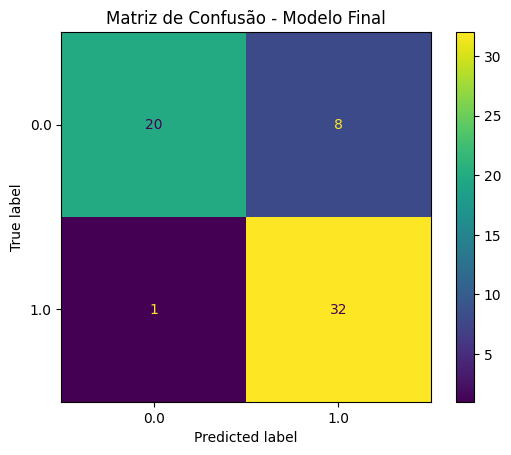

In [118]:
# === Avaliação final ===

if search is not None and hasattr(search, "best_estimator_"):
    final_model = search.best_estimator_
    final_model_name = "RandomForest_otimizado"

else:
    # Escolhe o melhor modelo com base no F1-score
    best_model_name = max(
        results,
        key=lambda x: results[x]["f1"]
    )

    final_model_name = best_model_name
    final_model = trained_models[best_model_name]


print("Modelo final:", final_model_name)


# Avaliação no conjunto de teste

if final_model is not None and PROBLEM_TYPE == "classificacao":

    y_pred = final_model.predict(X_test)

    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_estimator(
        final_model,
        X_test,
        y_test
    )

    plt.title("Matriz de Confusão - Modelo Final")
    plt.show()

## 10.1 Análise de erros e limitações

A análise dos resultados permite identificar que o modelo pode cometer erros de classificação, como falsos positivos (indicar risco de doença quando não há) e falsos negativos (não identificar um paciente com possível doença cardíaca). Em aplicações de saúde, os falsos negativos são especialmente relevantes, pois podem atrasar uma avaliação médica.

As métricas utilizadas, como F1-score, precisão e recall, são adequadas para avaliar o equilíbrio entre os tipos de erro. Entretanto, o desempenho do modelo depende da qualidade e representatividade do dataset utilizado, podendo apresentar limitações ao ser aplicado em diferentes populações.

O modelo não deve ser utilizado como substituto de diagnóstico médico, mas sim como ferramenta de apoio à decisão. Novos dados e validações externas seriam necessários antes de uma aplicação em ambiente real.

# 11. Comparação final dos modelos

| Modelo                     | Métrica principal (F1-score) | Outras métricas                  | Tempo de treino | Observações                                         |
| -------------------------- | ---------------------------- | -------------------------------- | --------------- | --------------------------------------------------- |
| Baseline (DummyClassifier) | 0.379840      | Accuracy, Precision, Recall, AUC | 0.010       | Modelo de referência, prevê a classe mais frequente |
| LogisticRegression         | 0.799672      | Accuracy, Precision, Recall, AUC | 0.010       | Modelo simples, rápido e interpretável              |
| RandomForest               | 0.831266     | Accuracy, Precision, Recall, AUC | 0.213       | Modelo capaz de capturar relações não lineares      |



# 12. Boas práticas e rastreabilidade

| Decisão                                       | Justificativa                                                       | Impacto esperado                                                      |
| --------------------------------------------- | ------------------------------------------------------------------- | --------------------------------------------------------------------- |
| Utilizar `SEED = 42`                          | Garantir reprodutibilidade dos resultados                           | Permitir que os experimentos sejam repetidos com os mesmos resultados |
| Divisão treino/teste 80/20 com estratificação | Preservar a proporção das classes de doença e não doença            | Avaliação mais confiável do modelo                                    |
| Utilizar Pipeline de pré-processamento        | Aplicar transformações apenas no treino e evitar vazamento de dados | Melhorar a confiabilidade da avaliação                                |
| Imputação pela mediana                        | Reduzir impacto de valores extremos nas variáveis numéricas         | Manter a qualidade dos dados                                          |
| Padronização com StandardScaler               | Ajustar escalas diferentes entre variáveis                          | Melhorar o desempenho de modelos sensíveis à escala                   |
| Usar F1-score como métrica principal          | Considerar equilíbrio entre precisão e recall                       | Avaliar melhor os erros de classificação                              |
| Modelo baseline DummyClassifier               | Criar referência mínima de comparação                               | Verificar se os modelos aprendem padrões relevantes                   |
| Testar LogisticRegression                     | Modelo simples, rápido e interpretável                              | Criar uma comparação inicial                                          |
| Testar RandomForest                           | Capturar relações não lineares nos dados                            | Aumentar capacidade preditiva                                         |
| Otimizar RandomForest com RandomizedSearchCV  | Buscar melhores combinações de hiperparâmetros                      | Melhorar o desempenho do modelo final                                 |
| Não utilizar GPU                              | Dataset pequeno e modelos leves                                     | Reduzir complexidade e custo computacional                            |


# 13. Conclusão

O objetivo deste MVP foi desenvolver e avaliar modelos de Machine Learning para prever a presença de doença cardíaca com base em características clínicas dos pacientes. Foram testados modelos de classificação supervisionada, incluindo um baseline, Regressão Logística e Random Forest, e os resultados mostraram que os modelos candidatos superaram o baseline, indicando aprendizado de padrões relevantes nos dados.

A solução final foi escolhida principalmente pelo F1-score, buscando equilíbrio entre os casos corretamente identificados. O projeto reforçou a importância da análise exploratória, do pré-processamento e da validação para construir uma solução confiável.

Como limitações, o dataset é reduzido e pode não representar outros cenários, além de o modelo servir apenas como apoio à decisão médica. Como próximos passos, recomenda-se testar novos hiperparâmetros, usar bases maiores e realizar validações externas.
